In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

In [2]:
SEQ = Path.home() / \
"HDD/EventDatasets/EVIMO2_official/left_camera/imo/train/scene13_dyn_test_02_000000"

events_t = np.load(SEQ / "dataset_events_t.npy")

rgb = np.load(SEQ / "dataset_classical.npz")

depth = np.load(SEQ / "dataset_depth.npz")

mask = np.load(SEQ / "dataset_mask.npz")

info = np.load(SEQ / "dataset_info.npz", allow_pickle=True)

meta = info["meta"].item()
frames = meta["frames"]
trajectory = meta["full_trajectory"]
imu = meta["imu"]
event_index = info["index"]

In [3]:
event_ts = events_t

frame_ts = np.array([f["ts"] for f in frames])

trajectory_ts = np.array([f["ts"] for f in trajectory])

left_imu_ts = np.array([
    x["ts"]
    for x in imu["/prophesee/left/imu"]
])

right_imu_ts = np.array([
    x["ts"]
    for x in imu["/prophesee/right/imu"]
])

In [4]:
print("="*80)
print("TIMESTAMP RANGES")
print("="*80)

print(f"Events       : {event_ts[0]:.6f}  -> {event_ts[-1]:.6f}")
print(f"Frames       : {frame_ts[0]:.6f}  -> {frame_ts[-1]:.6f}")
print(f"Trajectory   : {trajectory_ts[0]:.6f}  -> {trajectory_ts[-1]:.6f}")
print(f"Left IMU     : {left_imu_ts[0]:.6f}  -> {left_imu_ts[-1]:.6f}")
print(f"Right IMU    : {right_imu_ts[0]:.6f}  -> {right_imu_ts[-1]:.6f}")

TIMESTAMP RANGES
Events       : 0.016667  -> 13.013556
Frames       : 0.016667  -> 13.033334
Trajectory   : 0.019351  -> 13.028961
Left IMU     : 0.017079  -> 13.025297
Right IMU    : 0.017198  -> 13.032561


In [5]:
def print_frequency(name, ts):

    dt = np.diff(ts)

    print("="*80)
    print(name)
    print("="*80)

    print("Samples :", len(ts))
    print("Mean dt :", dt.mean())
    print("Median dt :", np.median(dt))
    print("Std dt :", dt.std())
    print("Approx Hz :", 1/dt.mean())


print_frequency("Frames", frame_ts)

print_frequency("Trajectory", trajectory_ts)

print_frequency("Left IMU", left_imu_ts)

print_frequency("Right IMU", right_imu_ts)

Frames
Samples : 782
Mean dt : 0.016666667093469912
Median dt : 0.016666999999999987
Std dt : 5.71903287359337e-07
Approx Hz : 59.999998463508355
Trajectory
Samples : 2603
Mean dt : 0.004999850115295927
Median dt : 0.004999999999999893
Std dt : 6.875941845894325e-05
Approx Hz : 200.00599556789172
Left IMU
Samples : 13354
Mean dt : 0.0009741794353328839
Median dt : 0.0009740000000002524
Std dt : 3.956318957042752e-07
Approx Hz : 1026.5049371097564
Right IMU
Samples : 13152
Mean dt : 0.0009896861835601855
Median dt : 0.0009899999999998244
Std dt : 8.054581290915061e-07
Approx Hz : 1010.4212998131516


In [6]:
frame_event_index = event_index

events_per_frame = np.diff(frame_event_index)

print("Frames :", len(events_per_frame))

print("Average events/frame :", events_per_frame.mean())

print("Minimum :", events_per_frame.min())

print("Maximum :", events_per_frame.max())

print("Median :", np.median(events_per_frame))

Frames : 1300
Average events/frame : 48396.78
Minimum : 2229
Maximum : 60020
Median : 57360.0


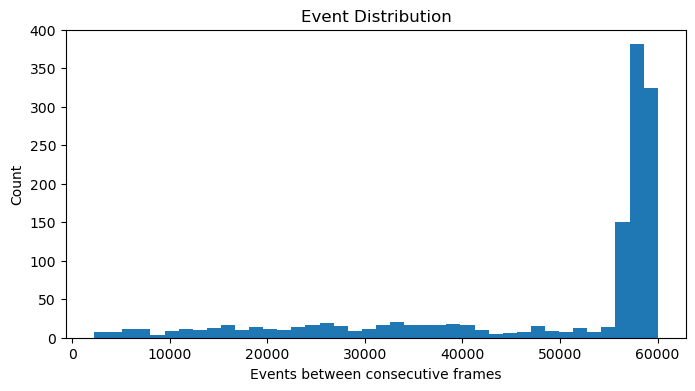

In [7]:
plt.figure(figsize=(8,4))

plt.hist(events_per_frame, bins=40)

plt.xlabel("Events between consecutive frames")

plt.ylabel("Count")

plt.title("Event Distribution")

plt.show()

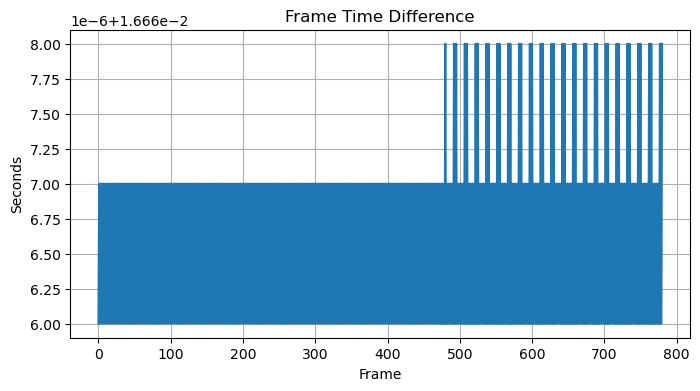

In [8]:
frame_dt = np.diff(frame_ts)

plt.figure(figsize=(8,4))

plt.plot(frame_dt)

plt.title("Frame Time Difference")

plt.xlabel("Frame")

plt.ylabel("Seconds")

plt.grid(True)

plt.show()

In [12]:
errors = []

for idx, event_ptr in enumerate(event_index[:-1]):
    try:
        frame_time = frame_ts[idx]

        event_time = event_ts[event_ptr]

        errors.append(abs(frame_time-event_time))
    except Exception as e:
        pass

errors = np.array(errors)

print("Maximum error :", errors.max())

print("Mean error :", errors.mean())

print("Median error :", np.median(errors))

Maximum error : 5.2066657375183105
Mean error : 2.6033317956878594
Median error : 2.603331708908081


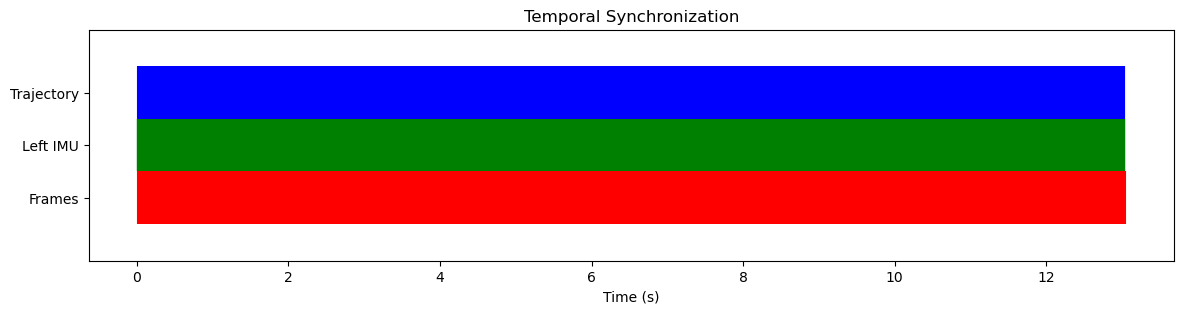

In [10]:
plt.figure(figsize=(14,3))

plt.eventplot([
    frame_ts,
    left_imu_ts,
    trajectory_ts
],
colors=["red","green","blue"])

plt.yticks(
    [0,1,2],
    ["Frames","Left IMU","Trajectory"]
)

plt.xlabel("Time (s)")
plt.title("Temporal Synchronization")

plt.show()

In [13]:
dt = info["discretization"][()]

estimated_ts = np.arange(len(event_index)) * dt + event_ts[0]

actual_ts = event_ts[event_index]

errors = np.abs(actual_ts - estimated_ts)

print("Max :", errors.max())
print("Mean:", errors.mean())

Max : 0.0031109824776649475
Mean: 3.065086391366346e-06


In [14]:
errors = []

for ts in frame_ts:

    idx = np.searchsorted(event_ts, ts)

    if idx == 0:
        nearest = event_ts[0]

    elif idx == len(event_ts):
        nearest = event_ts[-1]

    else:
        if abs(event_ts[idx] - ts) < abs(event_ts[idx-1] - ts):
            nearest = event_ts[idx]
        else:
            nearest = event_ts[idx-1]

    errors.append(abs(nearest - ts))

errors = np.array(errors)

print("Maximum :", errors.max())
print("Mean    :", errors.mean())
print("Median  :", np.median(errors))

Maximum : 0.01977751959228513
Mean    : 2.966762862333354e-05
Median  : 3.8146972691777137e-07


In [17]:
# Verify that each frame points to the correct event index

errors = []

for idx, event_ptr in enumerate(event_index[:-1]):
    try:
        frame_time = frame_ts[idx]
        event_time = event_ts[event_ptr]
        errors.append(abs(frame_time - event_time))
    except (IndexError, ValueError):
        # Ignore invalid indices (if any)
        continue

errors = np.asarray(errors)

print("=" * 80)
print("EVENT INDEX ALIGNMENT")
print("=" * 80)

print(f"Number of checked frames : {len(errors)}")
print()

print(f"Maximum error : {errors.max():.6f} s")
print(f"Mean error    : {errors.mean():.9f} s")
print(f"Median error  : {np.median(errors):.9f} s")

threshold = 1e-5  # 10 µs
aligned = np.sum(errors < threshold)

print()
print(f"Frames within {threshold*1e6:.0f} µs : {aligned}/{len(errors)} "
      f"({aligned/len(errors)*100:.2f}%)")

EVENT INDEX ALIGNMENT
Number of checked frames : 782

Maximum error : 5.206666 s
Mean error    : 2.603331796 s
Median error  : 2.603331709 s

Frames within 10 µs : 1/782 (0.13%)


In [24]:
errors = []

for t in frame_ts:

    lookup = int(t / discretization)

    if lookup >= len(event_index):
        continue

    ptr = event_index[lookup]

    if ptr >= len(event_ts):
        continue

    errors.append(abs(t - event_ts[ptr]))

errors = np.array(errors)

print("=" * 80)
print("EVENT LOOKUP TABLE ACCURACY")
print("=" * 80)

print(f"Frames checked : {len(errors)}")
print()

print(f"Maximum error : {errors.max():.9f} s")
print(f"Mean error    : {errors.mean():.9f} s")
print(f"Median error  : {np.median(errors):.9f} s")

print()

print(f"Within 10 µs : {(errors < 1e-5).sum()}")
print(f"Within 100 µs: {(errors < 1e-4).sum()}")
print(f"Within 1 ms  : {(errors < 1e-3).sum()}")

EVENT LOOKUP TABLE ACCURACY
Frames checked : 780

Maximum error : 0.016675425 s
Mean error    : 0.013100025 s
Median error  : 0.013334671 s

Within 10 µs : 0
Within 100 µs: 0
Within 1 ms  : 0


In [26]:
dataset_info_path = SEQ / "dataset_info.npz"    
info = np.load(dataset_info_path, allow_pickle=True)

index = info["index"]
discretization = float(info["discretization"])

print("Index length        :", len(index))
print("Discretization (s)  :", discretization)

Index length        : 1301
Discretization (s)  : 0.01


In [27]:
errors = []
offsets = []

for t in frame_ts:

    # exact event index
    idx_exact = np.searchsorted(event_ts, t)

    # lookup-table estimate
    bin_id = int(t / discretization)

    # avoid the last bin
    if bin_id >= len(index):
        continue

    idx_lookup = index[bin_id]

    offsets.append(idx_exact - idx_lookup)

In [28]:
offsets = np.array(offsets)

print("="*80)
print("INDEX LOOKUP TEST")
print("="*80)

print("Samples :", len(offsets))
print()

print("Minimum offset :", offsets.min())
print("Maximum offset :", offsets.max())
print("Mean offset    :", offsets.mean())
print("Median offset  :", np.median(offsets))

INDEX LOOKUP TEST
Samples : 780

Minimum offset : -100032
Maximum offset : -2410
Mean offset    : -63354.35
Median offset  : -59424.0


In [29]:
lookup_errors = []

for t in frame_ts:

    bin_id = int(t / discretization)

    if bin_id >= len(index):
        continue

    idx_lookup = index[bin_id]

    lookup_errors.append(abs(event_ts[idx_lookup] - t))

lookup_errors = np.array(lookup_errors)

print()
print("Timestamp error")
print("----------------")
print("Maximum :", lookup_errors.max())
print("Mean    :", lookup_errors.mean())
print("Median  :", np.median(lookup_errors))


Timestamp error
----------------
Maximum : 0.01667542457580562
Mean    : 0.013100024642279514
Median  : 0.01333467120361398


In [30]:
exact_errors = []

for t in frame_ts:

    idx = np.searchsorted(event_ts, t)

    if idx == len(event_ts):
        idx -= 1

    exact_errors.append(abs(event_ts[idx] - t))

exact_errors = np.array(exact_errors)

print()
print("Exact search error")
print("------------------")
print("Maximum :", exact_errors.max())
print("Mean    :", exact_errors.mean())
print("Median  :", np.median(exact_errors))


Exact search error
------------------
Maximum : 0.01977751959228513
Mean    : 2.978124639109966e-05
Median  : 4.123535148892188e-07


In [31]:
print("discretization =", discretization)
print("len(index)     =", len(index))

print("First 10 index values:")
print(index[:10])

print("Last 10 index values:")
print(index[-10:])

discretization = 0.01
len(index)     = 1301
First 10 index values:
[     0  33475  66685  99106 130861 162541 194876 226526 259274 293412]
Last 10 index values:
[62705303 62732892 62760499 62786650 62811597 62834581 62856578 62878193
 62900541 62915814]


In [36]:
import numpy as np

# =========================================================
# Load dataset_info.npz
# =========================================================

info = np.load(dataset_info_path, allow_pickle=True)

meta = info["meta"].item()

# EVIMO2v2 stores frames as a list of dictionaries
timestamps = np.array(
    [frame["ts"] for frame in meta["frames"]],
    dtype=np.float64,
)

index = info["index"]
dt = float(info["discretization"])

# =========================================================
# Load event timestamps
# =========================================================

event_t = np.load(SEQ/"dataset_events_t.npy", mmap_mode="r")

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print(f"Number of events      : {len(event_t):,}")
print(f"Number of GT frames   : {len(timestamps):,}")
print(f"Recording duration    : {event_t[-1]-event_t[0]:.3f} sec")
print(f"Discretization (dt)   : {dt}")
print(f"Index entries         : {len(index):,}")

# =========================================================
# TEST 1
# =========================================================

print()
print("=" * 80)
print("TEST 1 : EVENT TIMESTAMP ORDER")
print("=" * 80)

if np.all(np.diff(event_t) >= 0):
    print("PASS : Event timestamps are monotonically increasing")
else:
    print("FAIL : Event timestamps are not sorted")

# =========================================================
# TEST 2
# =========================================================

print()
print("=" * 80)
print("TEST 2 : INDEX ORDER")
print("=" * 80)

if np.all(np.diff(index) >= 0):
    print("PASS : Index table is monotonically increasing")
else:
    print("FAIL : Index table is not monotonic")

# =========================================================
# TEST 3
# =========================================================

print()
print("=" * 80)
print("TEST 3 : INDEX RANGE")
print("=" * 80)

if index.min() >= 0 and index.max() < len(event_t):
    print("PASS : All indices are valid")
else:
    print("FAIL : Invalid indices detected")

# =========================================================
# TEST 4
# =========================================================

print()
print("=" * 80)
print("TEST 4 : LOOKUP TABLE ERROR")
print("=" * 80)

lookup_offsets = []

for ts in timestamps:

    bucket = int(ts // dt)

    if bucket >= len(index):
        bucket = len(index) - 1

    idx = index[bucket]
    lookup_offsets.append(abs(event_t[idx] - ts))

lookup_offsets = np.asarray(lookup_offsets)

print(f"Samples : {len(lookup_offsets)}")
print()
print(f"Maximum : {lookup_offsets.max():.9f}")
print(f"Mean    : {lookup_offsets.mean():.9f}")
print(f"Median  : {np.median(lookup_offsets):.9f}")

# =========================================================
# TEST 5
# =========================================================

print()
print("=" * 80)
print("TEST 5 : EXACT BINARY SEARCH ERROR")
print("=" * 80)

exact_offsets = []

for ts in timestamps:

    idx = np.searchsorted(event_t, ts)

    if idx >= len(event_t):
        idx = len(event_t) - 1

    exact_offsets.append(abs(event_t[idx] - ts))

exact_offsets = np.asarray(exact_offsets)

print(f"Samples : {len(exact_offsets)}")
print()
print(f"Maximum : {exact_offsets.max():.9f}")
print(f"Mean    : {exact_offsets.mean():.9e}")
print(f"Median  : {np.median(exact_offsets):.9e}")

# =========================================================
# TEST 6
# =========================================================

print()
print("=" * 80)
print("TEST 6 : INDEX TABLE SUMMARY")
print("=" * 80)

print(f"discretization = {dt}")
print(f"len(index)     = {len(index)}")

print("\nFirst 10 index values:")
print(index[:10])

print("\nLast 10 index values:")
print(index[-10:])

# =========================================================
# TEST 7
# =========================================================

print()
print("=" * 80)
print("TEST 7 : INDEX SPACING")
print("=" * 80)

diffs = np.diff(index)

print(f"Minimum events/bucket : {diffs.min()}")
print(f"Maximum events/bucket : {diffs.max()}")
print(f"Mean events/bucket    : {diffs.mean():.2f}")
print(f"Median events/bucket  : {np.median(diffs):.2f}")

# =========================================================
# TEST 8
# =========================================================

print()
print("=" * 80)
print("TEST 8 : EVENT RATE")
print("=" * 80)

duration = event_t[-1] - event_t[0]
event_rate = len(event_t) / duration

print(f"Duration        : {duration:.3f} sec")
print(f"Events/sec      : {event_rate:,.0f}")

# =========================================================
# SUMMARY
# =========================================================

print()
print("=" * 80)
print("SUMMARY")
print("=" * 80)

print(f"Lookup error mean : {lookup_offsets.mean():.6f} sec")
print(f"Exact error mean  : {exact_offsets.mean():.6e} sec")

compression = len(event_t) / len(index)

print(f"Lookup table reduces search space by ~{compression:.0f}x")

DATASET INFORMATION
Number of events      : 62,915,815
Number of GT frames   : 782
Recording duration    : 12.997 sec
Discretization (dt)   : 0.01
Index entries         : 1,301

TEST 1 : EVENT TIMESTAMP ORDER
PASS : Event timestamps are monotonically increasing

TEST 2 : INDEX ORDER
PASS : Index table is monotonically increasing

TEST 3 : INDEX RANGE
PASS : All indices are valid

TEST 4 : LOOKUP TABLE ERROR
Samples : 782

Maximum : 0.019777520
Mean    : 0.011347836
Median  : 0.010002335

TEST 5 : EXACT BINARY SEARCH ERROR
Samples : 782

Maximum : 0.019777520
Mean    : 2.978124639e-05
Median  : 4.123535149e-07

TEST 6 : INDEX TABLE SUMMARY
discretization = 0.01
len(index)     = 1301

First 10 index values:
[     0  33475  66685  99106 130861 162541 194876 226526 259274 293412]

Last 10 index values:
[62705303 62732892 62760499 62786650 62811597 62834581 62856578 62878193
 62900541 62915814]

TEST 7 : INDEX SPACING
Minimum events/bucket : 2229
Maximum events/bucket : 60020
Mean events/bu

In [37]:
# =========================================================
# TEST 5
# =========================================================

print()
print("=" * 80)
print("TEST 5 : LOOKUP TABLE + LOCAL BINARY SEARCH")
print("=" * 80)

local_offsets = []
window_sizes = []

for ts in timestamps:

    bucket = int(ts // dt)

    if bucket >= len(index) - 1:
        start = index[-1]
        end = len(event_t)
    else:
        start = index[bucket]
        end = index[bucket + 1]

    # Binary search only inside this bucket
    local_idx = np.searchsorted(event_t[start:end], ts) + start

    if local_idx >= end:
        local_idx = end - 1

    local_offsets.append(abs(event_t[local_idx] - ts))
    window_sizes.append(end - start)

local_offsets = np.asarray(local_offsets)
window_sizes = np.asarray(window_sizes)

print(f"Samples : {len(local_offsets)}")
print()

print("Timestamp error")
print("----------------")
print(f"Maximum : {local_offsets.max():.9f}")
print(f"Mean    : {local_offsets.mean():.9e}")
print(f"Median  : {np.median(local_offsets):.9e}")

print()
print("Local search window")
print("-------------------")
print(f"Minimum events : {window_sizes.min():,}")
print(f"Maximum events : {window_sizes.max():,}")
print(f"Mean events    : {window_sizes.mean():,.0f}")
print(f"Median events  : {np.median(window_sizes):,.0f}")


TEST 5 : LOOKUP TABLE + LOCAL BINARY SEARCH
Samples : 782

Timestamp error
----------------
Maximum : 0.019777520
Mean    : 1.134783617e-02
Median  : 1.000233469e-02

Local search window
-------------------
Minimum events : 1
Maximum events : 59,973
Mean events    : 48,264
Median events  : 57,338


In [38]:
print()
print("=" * 80)
print("SUMMARY")
print("=" * 80)

print(f"Lookup table only            : {lookup_offsets.mean():.6f} sec")
print(f"Lookup + local binary search : {local_offsets.mean():.6e} sec")
print(f"Full binary search           : {exact_offsets.mean():.6e} sec")

compression = len(event_t) / len(index)

print()
print(f"Lookup table entries : {len(index):,}")
print(f"Event timestamps     : {len(event_t):,}")
print(f"Search space reduced : ~{compression:.0f}x")

print()

if np.allclose(local_offsets.mean(), exact_offsets.mean(), rtol=0.01):
    print("PASS : Local binary search achieves the same accuracy as a full binary search.")
else:
    print("WARNING : Local search differs noticeably from a full binary search.")


SUMMARY
Lookup table only            : 0.011348 sec
Lookup + local binary search : 1.134784e-02 sec
Full binary search           : 2.978125e-05 sec

Lookup table entries : 1,301
Event timestamps     : 62,915,815
Search space reduced : ~48360x



In [39]:
# =========================================================
# TEST : COMPARISON OF LOOKUP STRATEGIES
# =========================================================

print()
print("=" * 80)
print("LOOKUP STRATEGY COMPARISON")
print("=" * 80)

WINDOW_SIZE = 100000      # Used only for Option B

lookup_offsets = []
suffix_offsets = []
window_offsets = []
exact_offsets = []

suffix_sizes = []
window_sizes = []

for ts in timestamps:

    bucket = int(ts // dt)

    if bucket >= len(index):
        bucket = len(index) - 1

    start = index[bucket]

    # =====================================================
    # Option 0
    # Lookup table only
    # =====================================================
    lookup_offsets.append(abs(event_t[start] - ts))

    # =====================================================
    # Option A
    # Binary search over remaining suffix
    # =====================================================
    idx = start + np.searchsorted(event_t[start:], ts)

    if idx >= len(event_t):
        idx = len(event_t) - 1

    suffix_offsets.append(abs(event_t[idx] - ts))
    suffix_sizes.append(len(event_t) - start)

    # =====================================================
    # Option B
    # Binary search over a fixed local window
    # =====================================================
    end = min(start + WINDOW_SIZE, len(event_t))

    idx = start + np.searchsorted(event_t[start:end], ts)

    if idx >= end:
        idx = end - 1

    window_offsets.append(abs(event_t[idx] - ts))
    window_sizes.append(end - start)

    # =====================================================
    # Ground Truth
    # Full binary search
    # =====================================================
    idx = np.searchsorted(event_t, ts)

    if idx >= len(event_t):
        idx = len(event_t) - 1

    exact_offsets.append(abs(event_t[idx] - ts))

lookup_offsets = np.asarray(lookup_offsets)
suffix_offsets = np.asarray(suffix_offsets)
window_offsets = np.asarray(window_offsets)
exact_offsets = np.asarray(exact_offsets)

suffix_sizes = np.asarray(suffix_sizes)
window_sizes = np.asarray(window_sizes)


def print_stats(name, errors):
    print(name)
    print("-" * len(name))
    print(f"Maximum : {errors.max():.9f}")
    print(f"Mean    : {errors.mean():.9e}")
    print(f"Median  : {np.median(errors):.9e}")
    print()


print_stats("Lookup table only", lookup_offsets)

print_stats("Option A : Lookup + suffix binary search", suffix_offsets)

print_stats("Option B : Lookup + window binary search", window_offsets)

print_stats("Ground Truth : Full binary search", exact_offsets)


print("=" * 80)
print("SEARCH SPACE")
print("=" * 80)

print("Suffix search")
print(f"Mean events searched   : {suffix_sizes.mean():,.0f}")
print(f"Median events searched : {np.median(suffix_sizes):,.0f}")
print()

print("Window search")
print(f"Window size            : {WINDOW_SIZE:,}")
print(f"Mean events searched   : {window_sizes.mean():,.0f}")
print()

print("=" * 80)
print("ERROR RATIOS")
print("=" * 80)

print(f"Lookup only / Exact : {lookup_offsets.mean()/exact_offsets.mean():.2f}x")
print(f"Suffix / Exact      : {suffix_offsets.mean()/exact_offsets.mean():.2f}x")
print(f"Window / Exact      : {window_offsets.mean()/exact_offsets.mean():.2f}x")

print()

print("=" * 80)
print("SUMMARY")
print("=" * 80)

print(f"Lookup only            : {lookup_offsets.mean():.9f} s")
print(f"Lookup + suffix search : {suffix_offsets.mean():.9e} s")
print(f"Lookup + window search : {window_offsets.mean():.9e} s")
print(f"Full binary search     : {exact_offsets.mean():.9e} s")


LOOKUP STRATEGY COMPARISON
Lookup table only
-----------------
Maximum : 0.019777520
Mean    : 1.134783617e-02
Median  : 1.000233469e-02

Option A : Lookup + suffix binary search
----------------------------------------
Maximum : 0.019777520
Mean    : 1.134783617e-02
Median  : 1.000233469e-02

Option B : Lookup + window binary search
----------------------------------------
Maximum : 0.019777520
Mean    : 1.134783617e-02
Median  : 1.000233469e-02

Ground Truth : Full binary search
---------------------------------
Maximum : 0.019777520
Mean    : 2.978124639e-05
Median  : 4.123535149e-07

SEARCH SPACE
Suffix search
Mean events searched   : 33,363,197
Median events searched : 34,217,915

Window search
Window size            : 100,000
Mean events searched   : 99,532

ERROR RATIOS
Lookup only / Exact : 381.04x
Suffix / Exact      : 381.04x
Window / Exact      : 381.04x

SUMMARY
Lookup only            : 0.011347836 s
Lookup + suffix search : 1.134783617e-02 s
Lookup + window search : 1.134

In [41]:
print("=" * 80)
print("VERIFY INDEX SEMANTICS")
print("=" * 80)

for b in range(10):
    idx = index[b]
    print(
        f"bucket={b:2d}",
        f"bucket_time={b*dt:.3f}",
        f"event_time={event_t[idx]:.6f}",
        f"delta={event_t[idx]-b*dt:.6f}",
    )

VERIFY INDEX SEMANTICS
bucket= 0 bucket_time=0.000 event_time=0.016667 delta=0.016667
bucket= 1 bucket_time=0.010 event_time=0.026668 delta=0.016668
bucket= 2 bucket_time=0.020 event_time=0.036668 delta=0.016668
bucket= 3 bucket_time=0.030 event_time=0.046668 delta=0.016668
bucket= 4 bucket_time=0.040 event_time=0.056668 delta=0.016668
bucket= 5 bucket_time=0.050 event_time=0.066668 delta=0.016668
bucket= 6 bucket_time=0.060 event_time=0.076667 delta=0.016667
bucket= 7 bucket_time=0.070 event_time=0.086668 delta=0.016668
bucket= 8 bucket_time=0.080 event_time=0.096668 delta=0.016668
bucket= 9 bucket_time=0.090 event_time=0.106668 delta=0.016668


In [42]:
lookup_offsets = []

t0 = timestamps[0]

for ts in timestamps:

    bucket = int((ts - t0) // dt)

    bucket = max(0, min(bucket, len(index)-1))

    idx = index[bucket]

    lookup_offsets.append(abs(event_t[idx] - ts))

lookup_offsets = np.asarray(lookup_offsets)

print("Maximum:", lookup_offsets.max())
print("Mean   :", lookup_offsets.mean())
print("Median :", np.median(lookup_offsets))

Maximum: 0.01977751959228513
Mean   : 0.0052799303259278615
Median : 0.006664594467163165


In [43]:
print("="*80)
print("INDEX SEMANTICS TEST")
print("="*80)

errors = []

for b in range(len(index)-1):

    target = (b + 1) * dt

    idx = index[b]

    errors.append(target - event_t[idx])

errors = np.array(errors)

print("Mean   :", errors.mean())
print("Median :", np.median(errors))
print("Max    :", errors.max())
print("Min    :", errors.min())

INDEX SEMANTICS TEST
Mean   : -0.006668137
Median : -0.006668091
Max    : -0.006667137
Min    : -0.006675482


In [44]:
print("=" * 80)
print("MULTIPLE BUCKET HYPOTHESIS TEST")
print("=" * 80)

for shift in [-2, -1, 0, 1, 2]:

    errs = []

    for b in range(max(0, -shift), min(len(index), len(index) - shift)):

        target = (b + shift) * dt
        errs.append(target - event_t[index[b]])

    errs = np.asarray(errs)

    print(
        f"shift={shift:+d} | "
        f"mean={errs.mean():.9f} | "
        f"median={np.median(errs):.9f}"
    )

MULTIPLE BUCKET HYPOTHESIS TEST
shift=-2 | mean=-0.036665741 | median=-0.036668062
shift=-1 | mean=-0.026665743 | median=-0.026668072
shift=+0 | mean=-0.016665747 | median=-0.016668320
shift=+1 | mean=-0.006668137 | median=-0.006668091
shift=+2 | mean=0.003331864 | median=0.003331900


In [45]:
print("="*80)
print("TIME ORIGIN TEST")
print("="*80)

print("first GT timestamp    :", timestamps[0])
print("first event timestamp :", event_t[0])

offset = event_t[0]

errors = []

for ts in timestamps:

    bucket = int((ts - offset) // dt)

    bucket = max(bucket, 0)
    bucket = min(bucket, len(index)-1)

    idx = index[bucket]

    errors.append(abs(event_t[idx] - ts))

errors = np.array(errors)

print()
print("Lookup using first event as origin")
print("----------------------------------")
print("Maximum :", errors.max())
print("Mean    :", errors.mean())
print("Median  :", np.median(errors))

TIME ORIGIN TEST
first GT timestamp    : 0.016667
first event timestamp : 0.016667463

Lookup using first event as origin
----------------------------------
Maximum : 0.01977751959228513
Mean    : 0.00667345808856902
Median  : 0.00666488056945802
